In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

In [6]:
data = {
    'Date': [
        '2020-04-01', '2020-05-01', '2020-06-01', '2020-07-01', '2020-08-01',
        '2020-09-01', '2020-10-01', '2020-11-01', '2020-12-01', '2021-01-01',
        '2021-02-01', '2021-03-01', '2021-04-01', '2021-05-01', '2021-06-01',
        '2021-07-01', '2021-08-01', '2021-09-01', '2021-10-01', '2021-11-01',
        '2021-12-01', '2022-01-01'
    ],
    'Value': [
        1501, 1253, 1226, 1484, 2009, 2132, 1231, 1035, 511, 2167,
        930, 1140, 961, 1018, 1009, 5507, 15545, 4504, 7335, 6890,
        1425, 1793
    ]
}
df = pd.DataFrame(data)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df = df.asfreq('MS')

In [7]:
def check_stationarity(series, name=""):
    adf_test = adfuller(series.dropna())
    print(f'{name} ADF Statistic: {adf_test[0]:.4f}, p-value: {adf_test[1]:.4f}')
    if adf_test[1] < 0.05:
        print("Ряд стационарен")
        return True
    else:
        print("Ряд не стационарен")
        return False

def make_stationary(series, window=3):
    log_series = np.log(series)
    rolling_mean = log_series.rolling(window=window).mean()
    differenced = rolling_mean.diff()
    return log_series, rolling_mean, differenced

def smape(a, f):
    return 100/len(a) * np.sum(2 * np.abs(f - a) / (np.abs(a) + np.abs(f) + 1e-8))

def val_metrics(name, actual, pred):
    if len(actual) != len(pred):
        min_len = min(len(actual), len(pred))
        actual, pred = actual[:min_len], pred[:min_len]
    
    mse = mean_squared_error(actual, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, pred)
    sm = smape(actual, pred)
    return {'model': name, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'SMAPE': sm}

Проверка стационарности исходного ряда:
Original ADF Statistic: -1.6715, p-value: 0.4458
Ряд не стационарен

Проверка стационарности после преобразований:
Differenced ADF Statistic: -3.0474, p-value: 0.0307
Ряд стационарен


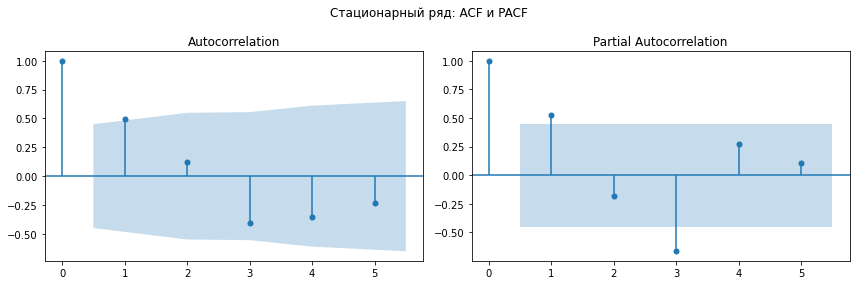

In [8]:
test_size = 6
p_max = 3
q_max = 3
h = test_size
use_bias_correction = True
df = df.copy()
outlier_dates = [
    pd.Timestamp('2021-07-01'), pd.Timestamp('2021-08-01'),
    pd.Timestamp('2021-10-01'), pd.Timestamp('2021-11-01')
]

df['outlier'] = 0
for d in outlier_dates:
    if d in df.index: df.loc[d, 'outlier'] = 1

print("Проверка стационарности исходного ряда:")
check_stationarity(df['Value'], "Original")

df['Log_Value'], df['Rolling_Mean'], df['Differenced'] = make_stationary(df['Value'])
df_stationary = df.dropna().copy()

print("\nПроверка стационарности после преобразований:")
is_stationary = check_stationarity(df_stationary['Differenced'], "Differenced")

if is_stationary:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(df_stationary['Differenced'], lags=5, ax=ax1)
    plot_pacf(df_stationary['Differenced'], lags=5, ax=ax2)
    plt.suptitle('Стационарный ряд: ACF и PACF')
    plt.tight_layout()
    plt.show()

In [14]:
train_stationary = df_stationary.iloc[:-test_size].copy()
test_stationary = df_stationary.iloc[-test_size:].copy()
exog_train_stationary = train_stationary[['outlier']]

# Определяем test на исходных данных
test = df.iloc[-test_size:].copy()

def select_arima_aic(y, p_max=3, d=0, q_max=3, exog=None):
    best_aic, best_model, best_order = np.inf, None, None
    
    for p in range(p_max + 1):
        for q in range(q_max + 1):
            try:
                model = ARIMA(y, order=(p, d, q), exog=exog).fit()
                if model.aic < best_aic:
                    best_aic, best_model, best_order = model.aic, model, (p, d, q)
            except:
                continue
    return best_order, best_model

print("\nARIMA МОДЕЛИ НА СТАЦИОНАРНЫХ ДАННЫХ")
print("="*50)

order_base, model_base = select_arima_aic(
    train_stationary['Differenced'], p_max, 0, q_max, None)
order_exog, model_exog = select_arima_aic(
    train_stationary['Differenced'], p_max, 0, q_max, exog_train_stationary)

print(f"ARIMA baseline order: {order_base}, AIC: {model_base.aic:.2f}")
print(f"ARIMA with outliers order: {order_exog}, AIC: {model_exog.aic:.2f}")

print("\nПроверка стационарности остатков:")
check_stationarity(model_base.resid, "ARIMA baseline residuals")
check_stationarity(model_exog.resid, "ARIMA with outliers residuals")

def inverse_stationary_transform(diff_forecast, last_rolling_mean):
    rolling_forecast = []
    current = last_rolling_mean
    
    for diff in diff_forecast:
        current += diff
        rolling_forecast.append(current)
    
    log_forecast = np.array(rolling_forecast)
    original_forecast = np.exp(log_forecast)
    return original_forecast, log_forecast

def forecast_arima_stationary(model, steps, last_rolling_mean, freq, exog_future=None):
    fc_res = model.get_forecast(steps=steps, exog=exog_future)
    diff_forecast = fc_res.predicted_mean
    
    original_forecast, log_forecast = inverse_stationary_transform(diff_forecast, last_rolling_mean)
    
    idx = pd.date_range(
        start=df.index[-1] + pd.tseries.frequencies.to_offset(freq), 
        periods=steps, freq=freq
    )
    
    return pd.DataFrame({
        'value': original_forecast,
        'log_forecast': log_forecast,
        'diff_forecast': diff_forecast.values
    }, index=idx)

freq = df.index.freq or 'MS'
last_rolling_mean = train_stationary['Rolling_Mean'].iloc[-1]
exog_future_zero = pd.DataFrame({'outlier': np.zeros(h)}, index=pd.date_range(
    start=df.index[-1] + pd.tseries.frequencies.to_offset(freq), periods=h, freq=freq))

fc_arima_base = forecast_arima_stationary(model_base, h, last_rolling_mean, freq)
fc_arima_exog = forecast_arima_stationary(model_exog, h, last_rolling_mean, freq, exog_future_zero)

# =============================================================================
# ETS МОДЕЛЬ
# =============================================================================
ets_model = ExponentialSmoothing(
    df.iloc[:-test_size]['Value'], 
    trend='add', 
    seasonal=None, 
    damped_trend=True
).fit(optimized=True)

fc_ets = pd.DataFrame({
    'value': ets_model.forecast(h).values
}, index=pd.date_range(
    start=df.index[-1] + pd.tseries.frequencies.to_offset(freq), 
    periods=h, freq=freq
))


ARIMA МОДЕЛИ НА СТАЦИОНАРНЫХ ДАННЫХ
ARIMA baseline order: (3, 0, 0), AIC: 4.13
ARIMA with outliers order: (0, 0, 3), AIC: -2.60

Проверка стационарности остатков:
ARIMA baseline residuals ADF Statistic: -1.7934, p-value: 0.3838
Ряд не стационарен
ARIMA with outliers residuals ADF Statistic: -2.9776, p-value: 0.0370
Ряд стационарен



СРАВНЕНИЕ МОДЕЛЕЙ (МЕТРИКИ)
                              MSE         RMSE          MAE      SMAPE
model                                                                 
ETS                  3.535627e+07  5946.113541  4476.667159  83.792794
ARIMA-with-outliers  4.372087e+07  6612.175657  4717.236673  89.859571
ARIMA-baseline       4.588496e+07  6773.843948  4905.529935  98.237616

ДЕТАЛЬНОЕ СРАВНЕНИЕ ПРОГНОЗОВ С ФАКТИЧЕСКИМИ ЗНАЧЕНИЯМИ
Детальное сравнение по периодам:
        Дата  Фактическое  ARIMA_baseline  ARIMA_outliers      ETS  \
0 2021-08-01        15545         1623.39         1707.31  2527.30   
1 2021-09-01         4504         1599.51         1606.13  2825.12   
2 2021-10-01         7335         1031.37         1557.90  3120.01   
3 2021-11-01         6890         1129.89         1511.19  3411.99   
4 2021-12-01         1425         1140.48         1465.88  3701.09   
5 2022-01-01         1793         1534.18         1421.92  3987.33   

   Ошибка_ARIMA_baseline  Ошибка_AR

<Figure size 1008x864 with 0 Axes>

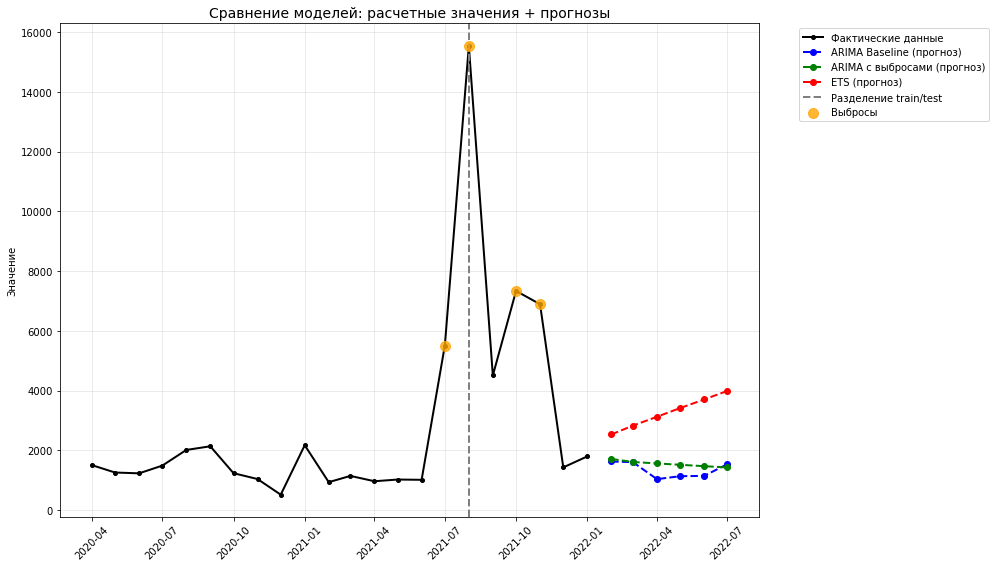

In [21]:
# =============================================================================
# ДЕТАЛЬНОЕ СРАВНЕНИЕ ПРОГНОЗОВ С ФАКТИЧЕСКИМИ ЗНАЧЕНИЯМИ
# =============================================================================
results = []

# Метрики для моделей
results.append(val_metrics('ARIMA-baseline', test['Value'].values, fc_arima_base['value'].values))
results.append(val_metrics('ARIMA-with-outliers', test['Value'].values, fc_arima_exog['value'].values))
results.append(val_metrics('ETS', test['Value'].values, fc_ets['value'].values))

res_df = pd.DataFrame(results).set_index('model')
print("\n" + "="*50)
print("СРАВНЕНИЕ МОДЕЛЕЙ (МЕТРИКИ)")
print("="*50)
print(res_df.sort_values('RMSE'))

# =============================================================================
# ДЕТАЛЬНАЯ ТАБЛИЦА СРАВНЕНИЯ ПРОГНОЗОВ
# =============================================================================
print("\n" + "="*70)
print("ДЕТАЛЬНОЕ СРАВНЕНИЕ ПРОГНОЗОВ С ФАКТИЧЕСКИМИ ЗНАЧЕНИЯМИ")
print("="*70)

# Создаем DataFrame для детального сравнения
comparison_df = pd.DataFrame({
    'Дата': test.index,
    'Фактическое': test['Value'].values
})

# Добавляем прогнозы каждой модели
comparison_df['ARIMA_baseline'] = fc_arima_base['value'].values
comparison_df['ARIMA_outliers'] = fc_arima_exog['value'].values
comparison_df['ETS'] = fc_ets['value'].values

# Добавляем ошибки
comparison_df['Ошибка_ARIMA_baseline'] = comparison_df['Фактическое'] - comparison_df['ARIMA_baseline']
comparison_df['Ошибка_ARIMA_outliers'] = comparison_df['Фактическое'] - comparison_df['ARIMA_outliers']
comparison_df['Ошибка_ETS'] = comparison_df['Фактическое'] - comparison_df['ETS']

# Добавляем процентные ошибки
comparison_df['Ошибка_%_ARIMA_baseline'] = (comparison_df['Ошибка_ARIMA_baseline'] / comparison_df['Фактическое']) * 100
comparison_df['Ошибка_%_ARIMA_outliers'] = (comparison_df['Ошибка_ARIMA_outliers'] / comparison_df['Фактическое']) * 100
comparison_df['Ошибка_%_ETS'] = (comparison_df['Ошибка_ETS'] / comparison_df['Фактическое']) * 100

# Выводим детальную таблицу
print("Детальное сравнение по периодам:")
print(comparison_df.round(2))

# Сводная статистика ошибок
print("\n" + "="*70)
print("СВОДНАЯ СТАТИСТИКА ОШИБОК ПРОГНОЗИРОВАНИЯ")
print("="*70)

error_stats = pd.DataFrame({
    'ARIMA_baseline': [
        comparison_df['Ошибка_ARIMA_baseline'].abs().mean(),
        comparison_df['Ошибка_%_ARIMA_baseline'].abs().mean(),
        comparison_df['Ошибка_ARIMA_baseline'].std()
    ],
    'ARIMA_outliers': [
        comparison_df['Ошибка_ARIMA_outliers'].abs().mean(),
        comparison_df['Ошибка_%_ARIMA_outliers'].abs().mean(),
        comparison_df['Ошибка_ARIMA_outliers'].std()
    ],
    'ETS': [
        comparison_df['Ошибка_ETS'].abs().mean(),
        comparison_df['Ошибка_%_ETS'].abs().mean(),
        comparison_df['Ошибка_ETS'].std()
    ]
}, index=['Средняя абсолютная ошибка', 'Средняя абсолютная % ошибка', 'Стандартное отклонение ошибки'])

print(error_stats.round(2))

# Анализ лучших прогнозов по периодам
print("\n" + "="*70)
print("АНАЛИЗ ЛУЧШИХ ПРОГНОЗОВ ПО ПЕРИОДАМ")
print("="*70)

best_forecasts = []
for i, row in comparison_df.iterrows():
    errors = {
        'ARIMA_baseline': abs(row['Ошибка_ARIMA_baseline']),
        'ARIMA_outliers': abs(row['Ошибка_ARIMA_outliers']),
        'ETS': abs(row['Ошибка_ETS'])
    }
    best_model = min(errors, key=errors.get)
    best_forecasts.append(best_model)

comparison_df['Лучшая_модель'] = best_forecasts

print("Распределение лучших прогнозов по моделям:")
print(comparison_df['Лучшая_модель'].value_counts())
plt.figure(figsize=(14, 12))


# График 1: Фактические значения и прогнозы
plt.figure(figsize=(14, 8))

# Фактические данные (вся история)
plt.plot(df.index, df['Value'], 'ko-', label='Фактические данные', linewidth=2, markersize=4)

# Прогнозы на тестовых данных
plt.plot(fc_arima_base.index, fc_arima_base['value'], 'bo--', label='ARIMA Baseline (прогноз)', linewidth=2, markersize=6)
plt.plot(fc_arima_exog.index, fc_arima_exog['value'], 'go--', label='ARIMA с выбросами (прогноз)', linewidth=2, markersize=6)
plt.plot(fc_ets.index, fc_ets['value'], 'ro--', label='ETS (прогноз)', linewidth=2, markersize=6)

# Выбросы
outlier_points = df[df['outlier'] == 1]
plt.scatter(outlier_points.index, outlier_points['Value'], color='orange', s=100, 
            label='Выбросы', zorder=5, alpha=0.8)

# Разделение train/test
plt.axvline(df.index[-test_size], color='gray', linestyle='--', linewidth=2, label='Разделение train/test')

plt.title('Сравнение моделей: расчетные значения + прогнозы', fontsize=14)
plt.ylabel('Значение')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [26]:
print("\nпрогнозные значения итого:\n", fc_ets['value'])


прогнозные значения итого:
 2022-02-01    2527.297056
2022-03-01    2825.122460
2022-04-01    3120.010015
2022-05-01    3411.988703
2022-06-01    3701.087217
2022-07-01    3987.333969
Freq: MS, Name: value, dtype: float64
